# Plot EU mortality due to exposure to PM<sub>2.5</sub> as a box plot

Taking the "EU" to be all grid cells within the SHERPA bounds

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from utils.utils import get_scenario_config, autosize_figure
import config
from utils.utils import require_dir
import pathlib

In [10]:
def process_mortality(GBD_version, scenario, year):
    # === Path config ===
    MORT_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "mortality")

    # === Load data ===
    file = f"EU_mortality_{GBD_version}_{n_samples}samples_{scenario}_{year}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    scenario = da.attrs["scenario"]
    year = da.attrs["year"]

    return da.expand_dims(scenario=[scenario], year=[year])

In [44]:
def plot_scenario_mortality(da_mean, year, scenario_longname, SAVE_DIR):
    # Compute summary stats per scenario: mean, median, and 95% CI (2.5/97.5 percentiles)
    means = da_mean.mean(dim="samples").values.flatten()
    medians = da_mean.median(dim="samples").values.flatten()
    lower = da_mean.quantile(0.025, dim="samples").values.flatten()
    upper = da_mean.quantile(0.975, dim="samples").values.flatten()

    # Asymmetric error bars from the mean out to the CI bounds
    lower_err = means - lower
    upper_err = upper - means

    fcolor = "#FEA571"
    plt.rcParams.update({'font.size': 16})

    y_pos = np.arange(1, len(da_mean.scenario) + 1)

    # Plot
    plt.figure(figsize=autosize_figure(1, 1, yscale_factor=2))

    # 95% CI whiskers
    plt.errorbar(means, y_pos, xerr=[lower_err, upper_err],
                 fmt="none", ecolor="gray", elinewidth=1,
                 capsize=4, capthick=1, zorder=1)

    # Mean markers
    plt.scatter(means, y_pos, color=fcolor, edgecolor="gray",
                s=200, zorder=3, label="Mean")

    # Median markers
    plt.scatter(medians, y_pos, facecolor="white", edgecolor="gray",
                marker="D", s=50, zorder=3, label="Median")

    plt.yticks(y_pos, scenario_longname)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Total PM$_{2.5}$ Mortality (year$^{-1}$)")
    plt.title(f"SHERPA EU {year}")
    plt.grid(axis="y", linestyle=':', alpha=0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.8)
    plt.legend(frameon=False, loc="upper right")

    plt.xlim(left=0)

    out_file = f"Mortality_pm25_scenario_meanCI_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    return

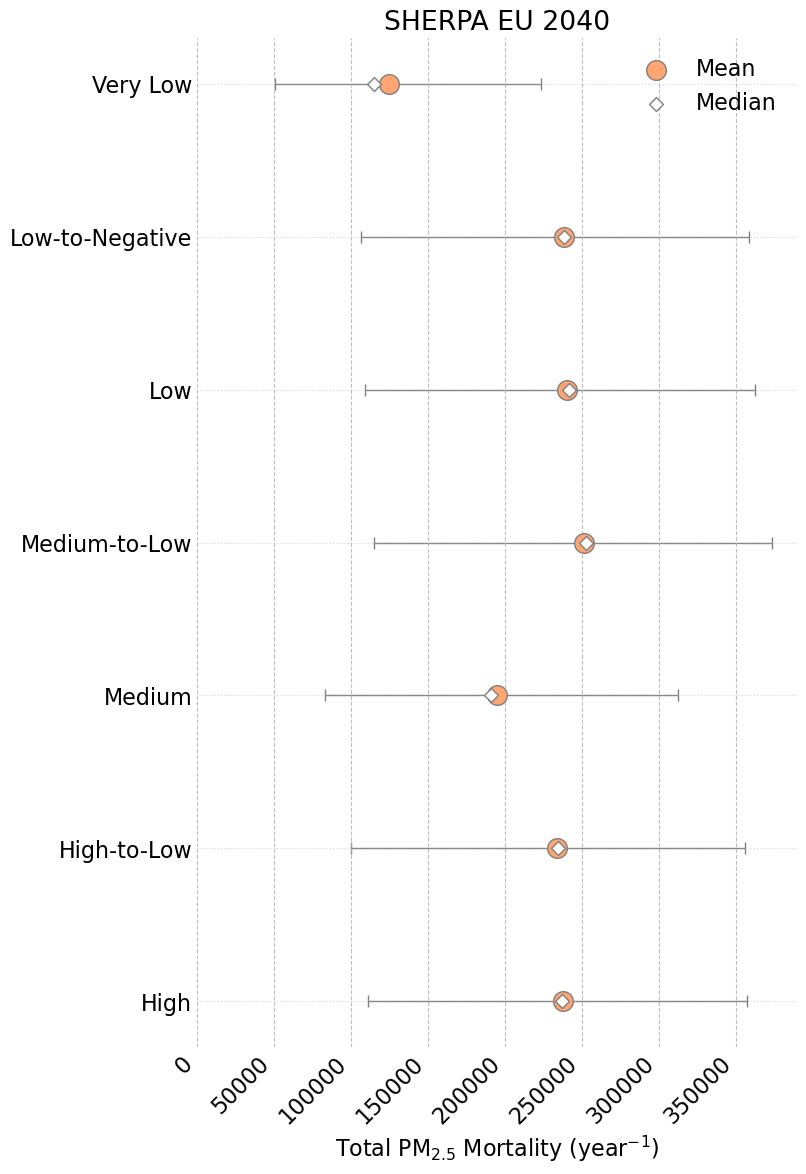

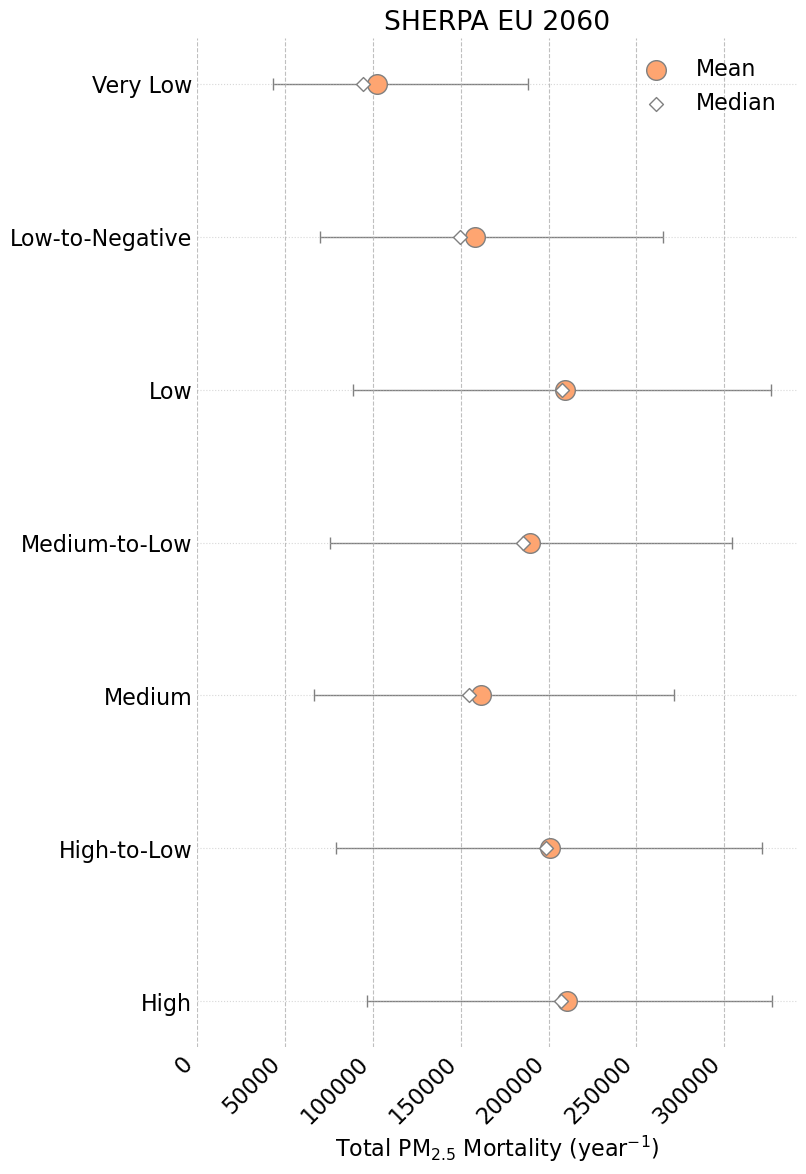

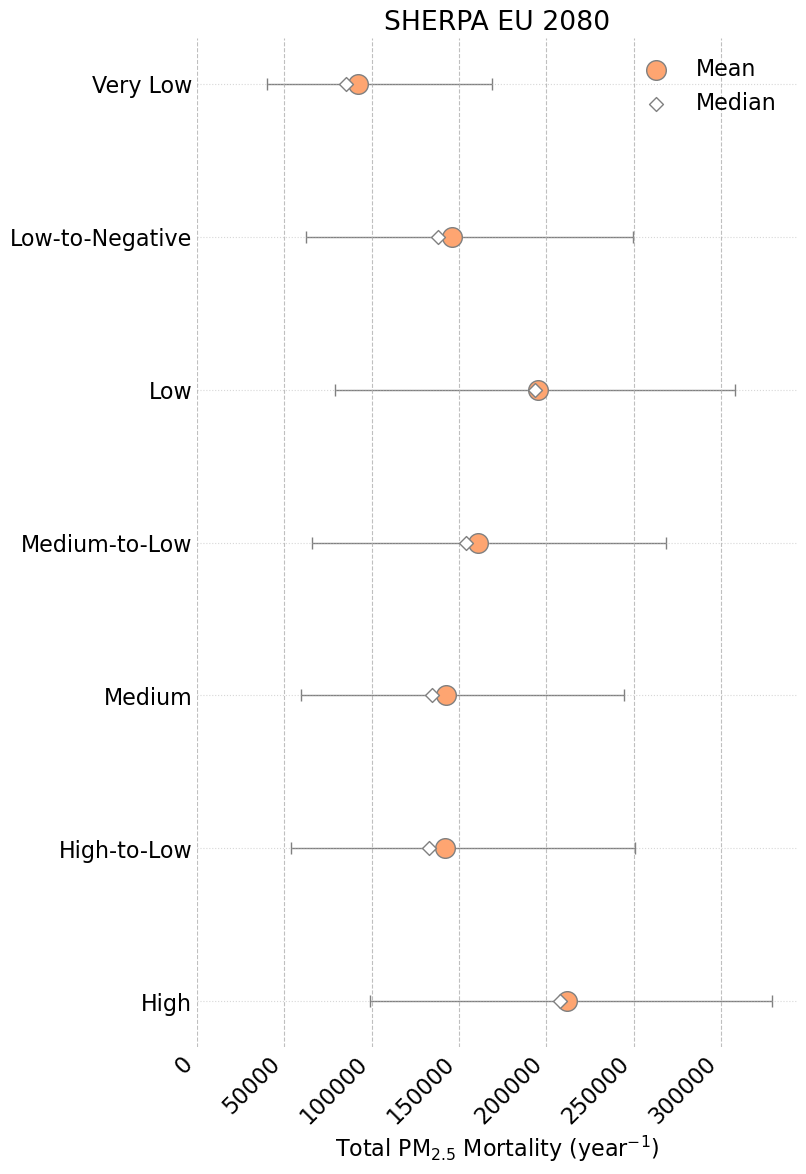

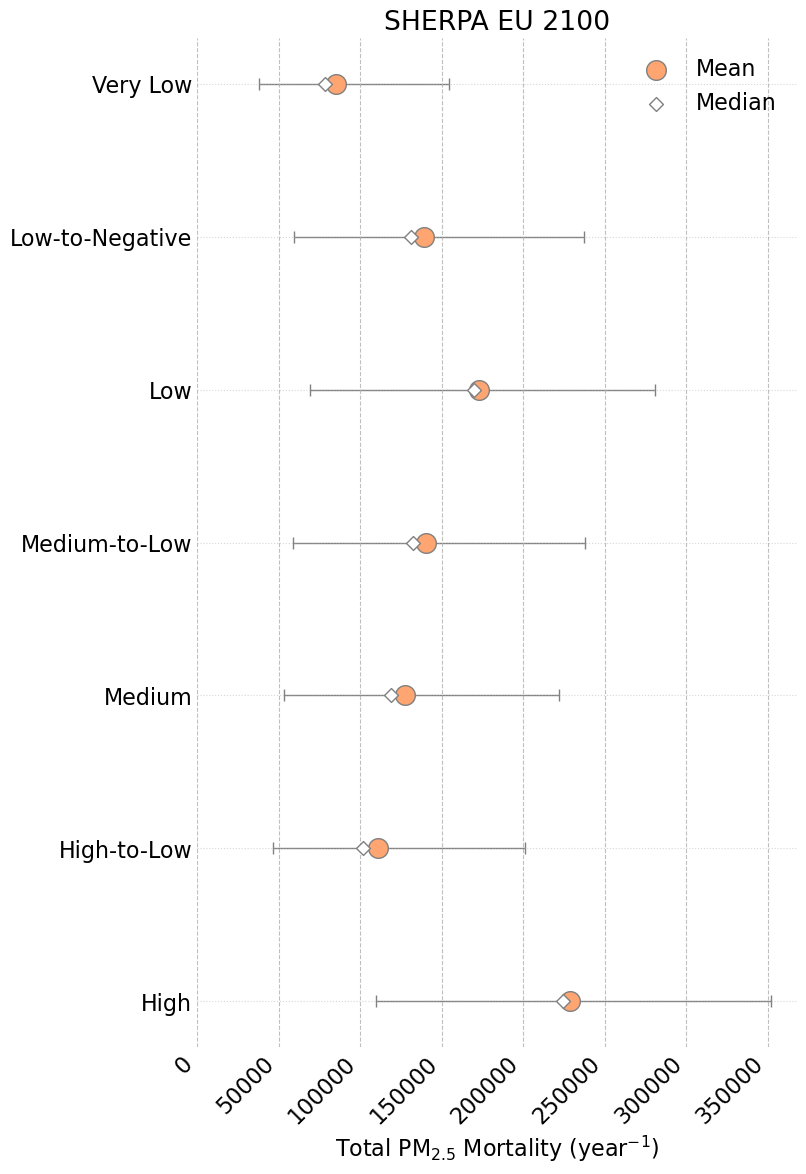

In [46]:
# === Scenario and path config ===
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "mortality" / "pm25" / "yearly")

GBD_version = "GBD23"
scenarios = ["H", "HL", "M", "ML", "L", "LN", "VL"]
scenario_longname = ["High", "High-to-Low", "Medium", "Medium-to-Low", "Low", "Low-to-Negative", "Very Low"]
years = [2040, 2060, 2080, 2100]

n_samples = 1000

for year in years:
    das = []
    for scenario in scenarios:
        da = process_mortality(GBD_version, scenario, year)
        das.append(da)
    da_scenarios = xr.concat(das, "scenario")

    # Plotting
    plt.rcParams.update({'font.size': 16})
    plot_scenario_mortality(da_scenarios, year, scenario_longname, SAVE_DIR)